# Library

In [1]:
import sys
sys.path.append("/project/assistant")

%load_ext autoreload
%autoreload 2

import os

# huggingface downloads: quiet text logs, no widget progress bars
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from elasticsearch import Elasticsearch
from openai import OpenAI

from cleaner import NoteCleaner
from embeddings import SentenceTransformerEmbeddings
from ingest import VaultLoader, SlidingWindowSplitter, ElasticsearchIndexer
from search import VaultSearcher

# Query Rewriting

The retrieval diagnosis leaves one important failure mode unresolved: vocabulary gaps. Some hard questions in the ground truth use wording that shares almost nothing with the target note—for example, “the thing doing the lookups” for a note about a search engine. When that happens, the correct note may never enter the candidate set, so reranking cannot recover it. Roughly one adversarial question in three still misses the top 10 for this reason.

Query rewriting addresses this by placing an LLM in front of retrieval. The model translates the user question into the vocabulary of the domain, and search runs on that rewritten query. In the example above, the LLM can map “the thing doing the lookups” to “search engine,” giving BM25 informative terms to match and the embedding model a more focused semantic representation.

Two rewriting strategies are compared against the hybrid baseline using the same evaluation suite from the retrieval notebook.

The first strategy replaces the original query with the rewritten version. This gives the rewrite maximum influence, but also introduces risk: a poor rewrite can damage an easy query that already retrieved the correct note.

The second strategy uses fusion. Hybrid search runs twice, once with the original query and once with the rewritten query, and the two rankings are combined with Reciprocal Rank Fusion. The original query preserves performance on the easy set, while the rewritten query provides a second path for recovering hard cases affected by vocabulary mismatch.


## Setup

In [2]:
# side index from the course corpus only (the ground truth's target),
# with source and folder matching the original vault layout, so the
# numbers align with the known baseline
INDEX = "rewrite_eval"

es = Elasticsearch(os.getenv("ELASTIC_HOST", "http://elasticsearch:9200"))
embeddings = SentenceTransformerEmbeddings(os.getenv("EMBED_MODEL", "all-MiniLM-L6-v2"))

docs = VaultLoader("/project/demo_vault/llm-zoomcamp-2026", NoteCleaner()).load()
for d in docs:
    d.metadata["source"] = "llm-zoomcamp-2026/" + d.metadata["source"]
    d.metadata["folder"] = "llm-zoomcamp-2026/" + d.metadata["folder"]
chunks = SlidingWindowSplitter(chunk_size=2000, chunk_overlap=1000).split_documents(docs)
print(f"{len(docs)} notes -> {len(chunks)} chunks")

indexer = ElasticsearchIndexer(es, embeddings, index=INDEX, add_context_header=True)
indexer.create_index(recreate=True)
indexer.index_documents(chunks)
es.indices.refresh(index=INDEX)

searcher = VaultSearcher(es, embeddings, INDEX)
gpt = OpenAI()
gt = pd.read_json("/project/data/claude_ground_truth.json")

51 notes -> 218 chunks


In [3]:
class QueryRewriter:
    """The translator in front of the search: rewrites a user question
    into the domain's vocabulary, at temperature zero. If the llm call
    fails, the original question comes back untouched: the translator
    can be absent, never in the way."""

    REWRITE_PROMPT = """
You rewrite search queries for a knowledge base about building RAG
systems: retrieval, embeddings, vector search, elasticsearch, llm
evaluation, monitoring, docker, and the tooling around them.

Rewrite the user question as a keyword-rich search query using the
vocabulary this domain would use in its notes. Keep the original
intent, expand vague references into concrete terms, and output ONLY
the rewritten query, nothing else.

Question: {question}
""".strip()

    def __init__(self, llm_client, model):
        self.llm_client = llm_client
        self.model = model

    def rewrite(self, question):
        """One translation for one question, original on any failure."""
        try:
            response = self.llm_client.chat.completions.create(
                model=self.model,
                temperature=0,
                messages=[{"role": "user", "content": self.REWRITE_PROMPT.format(
                    question=question)}],
            )
            rewritten = response.choices[0].message.content.strip()
            return rewritten if rewritten else question
        except Exception:
            return question


rewriter = QueryRewriter(gpt, model="gpt-5.4-mini")

The translator at work on the data it is measured on: hard questions
sampled from the ground truth file, original and rewritten side by
side, with the note each one should reach.

In [4]:
for q in gt[gt.difficulty == "hard"].sample(5, random_state=7).itertuples():
    print(f"original:  {q.question}")
    print(f"rewritten: {rewriter.rewrite(q.question)}")
    print(f"target:    {q.path}")
    print()

original:  where should the records go instead of a regular database once the volume gets serious
rewritten: high-volume record storage architecture alternatives to relational database for serious scale data persistence vector database document store search index object storage event store distributed database sharding partitioning ingestion pipeline RAG system data layer
target:    llm-zoomcamp-2026/05-monitoring/14-next-steps.md

original:  why is doing the api calls one at a time so painfully slow
rewritten: sequential API calls latency bottleneck throughput concurrency parallel requests batching async I/O rate limits performance optimization slow request handling
target:    llm-zoomcamp-2026/04-evaluation/03-ground-truth-batch.md

original:  how do i keep the helper from happily answering random board game trivia
rewritten: RAG assistant guardrails prevent irrelevant hallucinated answers board game trivia domain restriction answer only from retrieved context prompt engineering refu

In [5]:
def replace_search(query, num_results=10, folder=None):
    """Design 1: search with the rewritten query only."""
    return searcher.hybrid(rewriter.rewrite(query),
                           num_results=num_results, folder=folder)


def fused_search(query, num_results=10, k=60, folder=None):
    """Design 2: hybrid with the original AND the rewritten query,
    the two rankings merged with reciprocal rank fusion."""
    original = searcher.hybrid(query, num_results=num_results, folder=folder)
    rewritten = searcher.hybrid(rewriter.rewrite(query),
                                num_results=num_results, folder=folder)

    scores, hits = {}, {}
    for ranking in (original, rewritten):
        for rank, hit in enumerate(ranking):
            key = (hit["path"], hit["start"])
            scores[key] = scores.get(key, 0) + 1 / (k + rank + 1)
            hits[key] = hit
    ranked = sorted(scores, key=scores.get, reverse=True)
    return [{**hits[key], "_score": scores[key]} for key in ranked[:num_results]]


from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


def fused_rerank_search(query, num_results=10, candidates=30, folder=None):
    """Design 3: the two remedies stacked. Fused brings 30 candidates
    (the translator fixing PRESENCE), the cross-encoder rescores them
    reading query and chunk together (fixing POSITION), the best 10
    survive."""
    hits = fused_search(query, num_results=candidates, folder=folder)
    scores = cross_encoder.predict([(query, h["content"]) for h in hits])
    ranked = sorted(zip(hits, scores), key=lambda pair: -pair[1])
    return [{**h, "_score": float(s)} for h, s in ranked[:num_results]]

The bench: the same per-question analysis and the same visuals used
in the retrieval evaluation notebook, defined once and reused by
every section below.

In [6]:
def analyze_search(search_fn, questions, num_results=10):
    """One row per question: where the expected note landed and what
    took its place."""
    rows = []
    for q in tqdm(questions.itertuples(), total=len(questions)):
        paths = [r["path"] for r in search_fn(q.question, num_results=num_results)]
        rank = paths.index(q.path) + 1 if q.path in paths else None
        rows.append({"question": q.question, "difficulty": q.difficulty,
                     "expected": q.path, "rank": rank,
                     "hit": rank is not None,
                     "got_top1": paths[0] if paths else None})
    return pd.DataFrame(rows)


def metrics(frame):
    """Hit rate and mrr, overall and split by difficulty."""
    return pd.Series({
        "hit_rate": frame["hit"].mean(),
        "mrr": (1 / frame["rank"]).fillna(0).mean(),
        "easy_hit": frame[frame.difficulty == "easy"]["hit"].mean(),
        "hard_hit": frame[frame.difficulty == "hard"]["hit"].mean(),
        "easy_mrr": (1 / frame[frame.difficulty == "easy"]["rank"]).fillna(0).mean(),
        "hard_mrr": (1 / frame[frame.difficulty == "hard"]["rank"]).fillna(0).mean(),
    })


def plot_difficulty(frame, title):
    """The easy/hard pair for hit rate and mrr, house style."""
    m = metrics(frame)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
    for ax, pair, name in ((ax1, (m.easy_hit, m.hard_hit), "hit_rate"),
                           (ax2, (m.easy_mrr, m.hard_mrr), "mrr")):
        ax.bar(["easy", "hard"], pair, width=0.5,
               color=["#4a7ebb", "#c46a4a"])
        for i, v in enumerate(pair):
            ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
        ax.set_title(name)
        ax.set_ylim(0, 1.1)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_ranks(frame, title, color="#4a7ebb"):
    """Where the hits land: the rank distribution podium."""
    counts = frame[frame.hit]["rank"].value_counts().sort_index()
    plt.figure(figsize=(7, 3))
    plt.bar(counts.index, counts.values, color=color, width=0.7)
    for x, v in counts.items():
        plt.text(x, v + 1, str(int(v)), ha="center", fontsize=9)
    plt.xlabel("rank of the expected note (hits only)")
    plt.ylabel("questions")
    plt.title(title)
    plt.xticks(range(1, 11))
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

The measurement: the 200 ground truth questions through the three
configurations, cached to `data/query_rewriting_eval.csv` (about 3
cents and 4 minutes on the first pass; delete the file to re-run).
Every section below reads slices of this one dataframe.

In [7]:
RESULTS_PATH = Path("/project/data/query_rewriting_eval.csv")

CONFIGS = {
    "hybrid": searcher.hybrid,
    "replace": replace_search,
    "fused": fused_search,
    "fused_rerank": fused_rerank_search,
}

if RESULTS_PATH.exists():
    results = pd.read_csv(RESULTS_PATH)
    if "got_top1" not in results.columns:
        RESULTS_PATH.unlink()
        results = pd.DataFrame()
else:
    results = pd.DataFrame()

done = set(results["config"].unique()) if len(results) else set()
missing = [name for name in CONFIGS if name not in done]
if missing:
    frames = [results] if len(results) else []
    for name in missing:
        print(f"measuring {name}...")
        frame = analyze_search(CONFIGS[name], gt)
        frame["config"] = name
        frames.append(frame)
    results = pd.concat(frames, ignore_index=True)
    results.to_csv(RESULTS_PATH, index=False)
    print(f"saved: {len(results)} rows")
else:
    print(f"loaded cached results: {len(results)} rows")

hybrid_frame = results[results.config == "hybrid"]
replace_frame = results[results.config == "replace"]
fused_frame = results[results.config == "fused"]
fused_rerank_frame = results[results.config == "fused_rerank"]

measuring fused_rerank...


100%|██████████| 200/200 [29:53<00:00,  8.97s/it]

saved: 800 rows


# Baseline: hybrid

The reference: plain hybrid search, no rewriting, re-measured live on
this notebook's index. Expected to land on the known numbers (about
0.755 hit rate, 0.49 mrr), which doubles as the sanity check of the
side index.

hit_rate    0.755
mrr         0.491
easy_hit    0.980
hard_hit    0.680
easy_mrr    0.752
hard_mrr    0.405


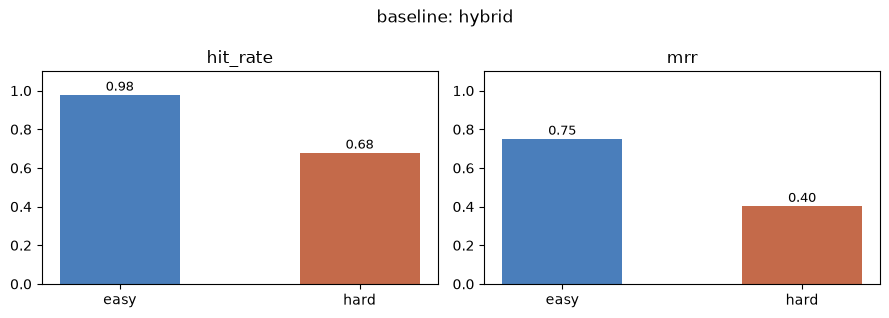

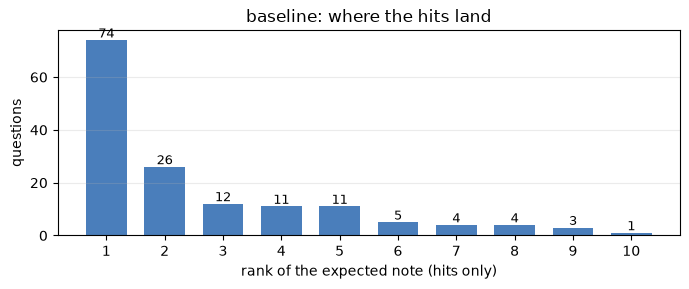

In [8]:
print(metrics(hybrid_frame).round(3).to_string())
plot_difficulty(hybrid_frame, "baseline: hybrid")
plot_ranks(hybrid_frame, "baseline: where the hits land")

# Design 1: replace

The search sees only the rewritten query. Maximum translation effect,
and maximum exposure: a rewrite that drifts from the intent loses
questions the original wording was already winning.

hit_rate    0.815
mrr         0.571
easy_hit    0.880
hard_hit    0.793
easy_mrr    0.712
hard_mrr    0.523


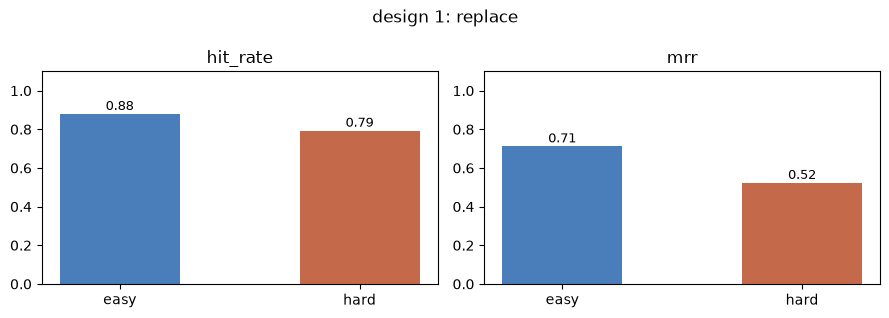

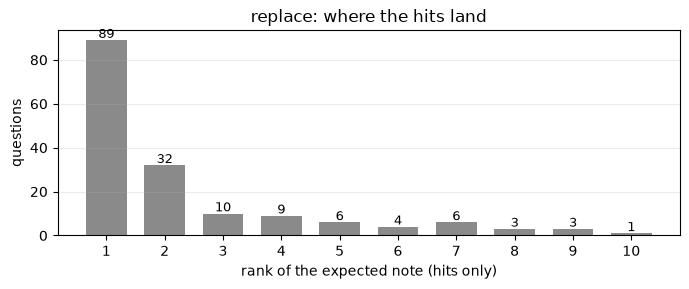

In [9]:
print(metrics(replace_frame).round(3).to_string())
plot_difficulty(replace_frame, "design 1: replace")
plot_ranks(replace_frame, "replace: where the hits land", color="#8a8a8a")

# Design 2: fused

Two hybrid searches, original and rewritten, merged with reciprocal
rank fusion. The original ranking protects what already works; the
translation adds candidates the original vocabulary cannot reach.

hit_rate    0.885
mrr         0.577
easy_hit    0.960
hard_hit    0.860
easy_mrr    0.801
hard_mrr    0.502


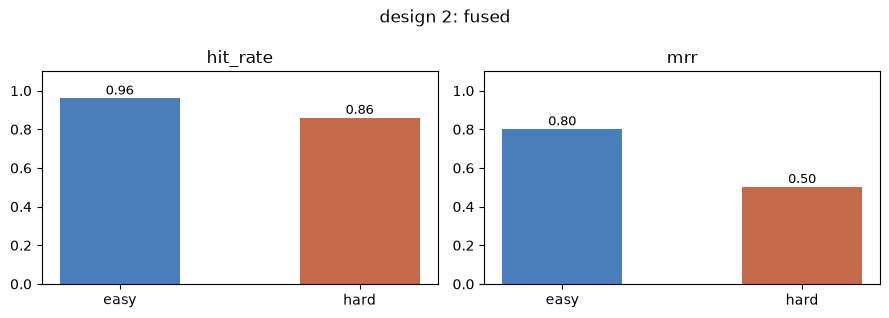

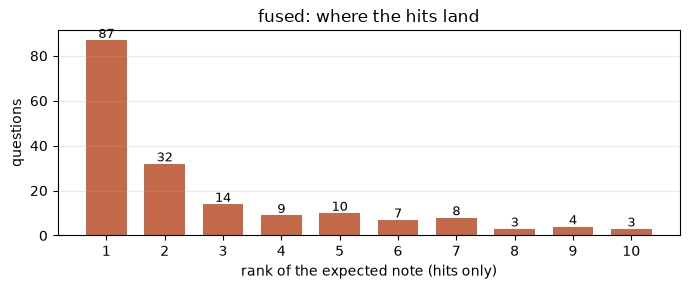

In [10]:
print(metrics(fused_frame).round(3).to_string())
plot_difficulty(fused_frame, "design 2: fused")
plot_ranks(fused_frame, "fused: where the hits land", color="#c46a4a")

# Design 3: fused + rerank

The two measured remedies stacked, each treating its own disease.
Fused fixes presence: the translator rescues questions whose
vocabulary never reaches the note, lifting hit rate. The cross-encoder
fixes position: it reads each question and candidate together and
reorders, lifting MRR. Fused brings 30 candidates, the cross-encoder
keeps the best 10. The cost is the reranker's latency, about 4 seconds
per question on cpu, which frames this as the quality mode
configuration.

hit_rate    0.810
mrr         0.556
easy_hit    0.960
hard_hit    0.760
easy_mrr    0.861
hard_mrr    0.454


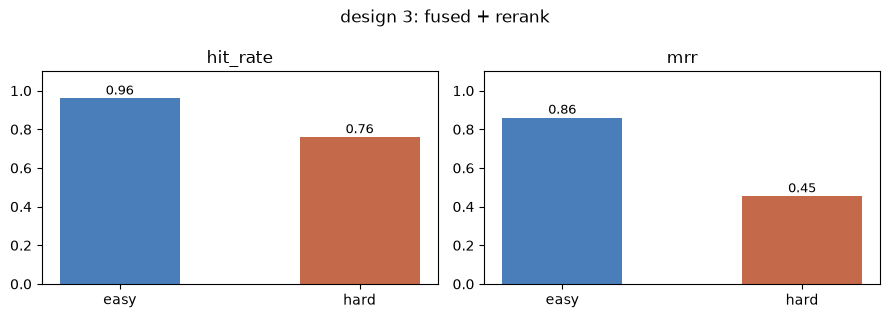

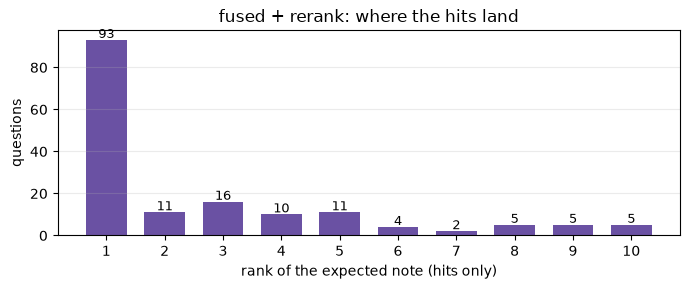

In [11]:
print(metrics(fused_rerank_frame).round(3).to_string())
plot_difficulty(fused_rerank_frame, "design 3: fused + rerank")
plot_ranks(fused_rerank_frame, "fused + rerank: where the hits land", color="#6a51a3")

# Comparison

In [12]:
summary = pd.DataFrame({
    "hybrid": metrics(hybrid_frame),
    "replace": metrics(replace_frame),
    "fused": metrics(fused_frame),
    "fused_rerank": metrics(fused_rerank_frame),
}).T.round(3)
summary

,hit_rate,mrr,easy_hit,hard_hit,easy_mrr,hard_mrr
hybrid,0.755,0.491,0.98,0.680,0.752,0.405
replace,0.815,0.571,0.88,0.793,0.712,0.523
fused,0.885,0.577,0.96,0.860,0.801,0.502
fused_rerank,0.810,0.556,0.96,0.760,0.861,0.454


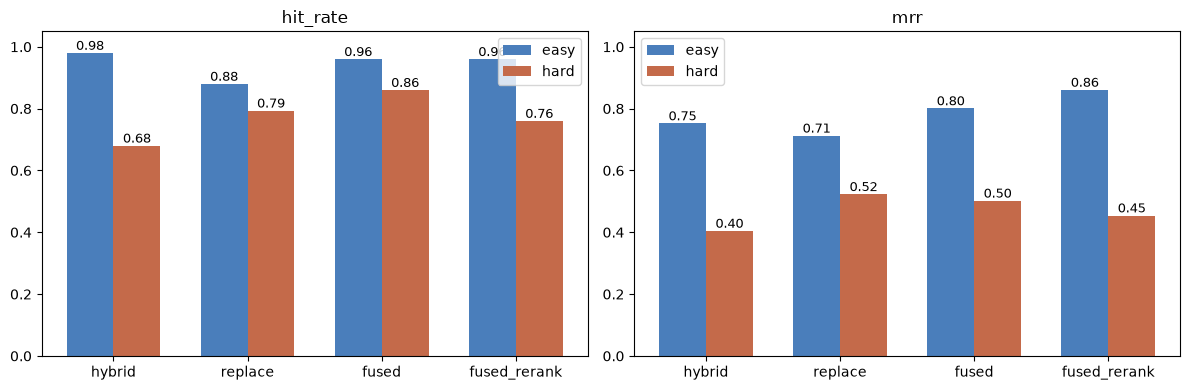

In [13]:
configs = ["hybrid", "replace", "fused", "fused_rerank"]
frames = {"hybrid": hybrid_frame, "replace": replace_frame,
          "fused": fused_frame, "fused_rerank": fused_rerank_frame}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(configs))
w = 0.35
for ax, key in ((ax1, "hit"), (ax2, "mrr")):
    suffix = "_hit" if key == "hit" else "_mrr"
    easy = [metrics(frames[c])["easy" + suffix] for c in configs]
    hard = [metrics(frames[c])["hard" + suffix] for c in configs]
    ax.bar(x - w/2, easy, w, label="easy", color="#4a7ebb")
    ax.bar(x + w/2, hard, w, label="hard", color="#c46a4a")
    for i, v in enumerate(easy):
        ax.text(i - w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    for i, v in enumerate(hard):
        ax.text(i + w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    ax.set_xticks(x, configs)
    ax.set_title("hit_rate" if key == "hit" else "mrr")
    ax.set_ylim(0, 1.05)
    ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# who flipped against the baseline: rescued and broken, by name
base = hybrid_frame.set_index("question")["hit"]
for name, frame in (("replace", replace_frame), ("fused", fused_frame),
                    ("fused_rerank", fused_rerank_frame)):
    conf = frame.set_index("question")["hit"]
    rescued = conf[conf & ~base]
    broken = conf[~conf & base]
    print(f"== {name}: +{len(rescued)} rescued, -{len(broken)} broken ==")
    for q in rescued.index[:6]:
        print(f"  + {q[:75]}")
    for q in broken.index[:6]:
        print(f"  - {q[:75]}")
    print()

== replace: +34 rescued, -22 broken ==
  + how do i make a hit in the original question count for more than a hit in t
  + why does sloppy wording in the template let the model drift off and invent 
  + why do i have to send the entire back and forth again on every single call
  + is there a shortcut to grab the reply text without digging through nested o
  + why is baking the knowledge straight into the model a pain to keep current
  + how could the smarter version help a student who writes in spanish
  - why do we split the documents into batches when generating the embeddings
  - why do we return five results instead of just the single best match
  - what do I need to change in my rag pipeline to use vector search instead of
  - why do my documents need unique ids before I can evaluate search
  - why use a second llm to compare the generated answer with the original one
  - why do we code the whole thing ourselves first instead of grabbing a ready 

== fused: +28 rescued, -2 broken 

In [15]:
# the remaining enemy: hard questions that still miss with the best
# config, and who steals their top-1
best = fused_rerank_frame   # the crowned design
survivors = best[(~best.hit) & (best.difficulty == "hard")]
print(f"{len(survivors)} hard questions still missing:")
survivors[["question", "expected", "got_top1"]].head(12)

36 hard questions still missing:


,question,expected,got_top1
657,if i want to switch to a different ai company ...,llm-zoomcamp-2026/01-agentic-rag/03-rag.md,llm-zoomcamp-2026/01-agentic-rag/16-other-fram...
660,how do we pull down the question lists for eve...,llm-zoomcamp-2026/01-agentic-rag/04-dataset.md,llm-zoomcamp-2026/04-evaluation/02-ground-trut...
663,how do i make a hit in the original question c...,llm-zoomcamp-2026/01-agentic-rag/05-search.md,llm-zoomcamp-2026/04-evaluation/06-search-tuni...
665,why does sloppy wording in the template let th...,llm-zoomcamp-2026/01-agentic-rag/06-building-p...,llm-zoomcamp-2026/01-agentic-rag/01-intro-agen...
666,how do the matched entries get squashed into o...,llm-zoomcamp-2026/01-agentic-rag/06-building-p...,llm-zoomcamp-2026/01-agentic-rag/05-search.md
668,why do i have to send the entire back and fort...,llm-zoomcamp-2026/01-agentic-rag/07-llm.md,llm-zoomcamp-2026/01-agentic-rag/13-function-c...
673,does the thing doing the lookups have to be a ...,llm-zoomcamp-2026/01-agentic-rag/08-rag-helper.md,llm-zoomcamp-2026/01-agentic-rag/01-intro-agen...
677,why is baking the knowledge straight into the ...,llm-zoomcamp-2026/01-agentic-rag/10-rag-next-s...,llm-zoomcamp-2026/01-agentic-rag/01-intro-agen...
678,how could the smarter version help a student w...,llm-zoomcamp-2026/01-agentic-rag/10-rag-next-s...,llm-zoomcamp-2026/01-agentic-rag/14-agentic-lo...
679,what did the teacher find when he went through...,llm-zoomcamp-2026/01-agentic-rag/10-rag-next-s...,llm-zoomcamp-2026/01-agentic-rag/14-agentic-lo...


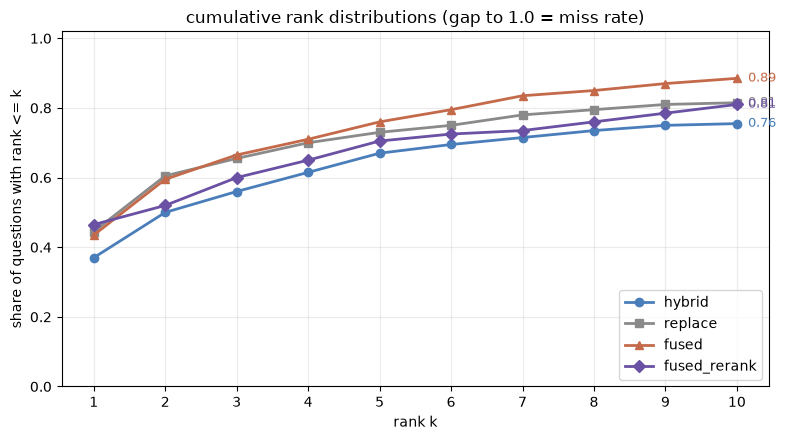

In [16]:
styles = {"hybrid": ("#4a7ebb", "o"), "replace": ("#8a8a8a", "s"),
          "fused": ("#c46a4a", "^"), "fused_rerank": ("#6a51a3", "D")}
ks = range(1, 11)

plt.figure(figsize=(8, 4.5))
for name, (color, marker) in styles.items():
    frame = results[results.config == name]
    curve = [(frame["rank"] <= k).mean() for k in ks]
    plt.plot(ks, curve, color=color, marker=marker, linewidth=2,
             markersize=6, label=name)
    plt.annotate(f"{curve[-1]:.2f}", (10, curve[-1]), xytext=(8, 0),
                 textcoords="offset points", color=color,
                 fontsize=9, va="center")
plt.xlabel("rank k")
plt.ylabel("share of questions with rank <= k")
plt.title("cumulative rank distributions (gap to 1.0 = miss rate)")
plt.xticks(list(ks))
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
